In [40]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pingouin as pg

### Question 2 (b)

In [38]:
df = pd.read_csv('HW1//Q2-data.csv')
df

,S,C,A,P,D,Y
0,0.304717,-0.257952,0.480994,0.893223,-1.814366,-1.929140
1,-1.039984,-0.299486,-0.140861,-0.334011,0.608024,-0.119146
2,0.750451,-0.696660,-0.721819,0.589327,-0.390804,-0.107619
3,0.940565,0.428483,0.655267,1.800798,-1.853337,-1.580398
4,-1.951035,0.234646,-1.121882,-1.061530,-1.876908,-2.272004
...,...,...,...,...,...,...
4995,1.077479,1.620106,1.496753,4.678687,-3.850905,-1.811464
4996,-0.343256,-0.063180,-0.349448,-1.196865,0.529180,0.026524
4997,0.780681,0.085249,-0.436188,1.446224,-1.790646,0.339099
4998,0.049741,1.124744,-0.939912,1.925502,-5.066322,-5.677786


In [ ]:
# Test A⊥C∣S,Y
pg.partial_corr(
    data=df,
    x='A',
    y='C',
    covar=['S','Y']
)

,n,r,CI95,p_val
pearson,5000,0.474869,"[0.45, 0.5]",1.414366e-279


We tested whether A⊥C∣S,Y with a partial correlation test under the Gaussian assumption.

The estimated partial correlation was r = 0.474869 with p-value = 1.414366e-279.

We reject the conditional independence, since the p-value is smaller than 0.05.

In [ ]:
# Test Y⊥A∣D,P
pg.partial_corr(
    data=df,
    x='Y',
    y='A',
    covar=['D','P']
)

,n,r,CI95,p_val
pearson,5000,-0.006363,"[-0.03, 0.02]",0.652912


We tested whether Y⊥A∣D,P with a partial correlation test under the Gaussian assumption.

The estimated partial correlation was -0.006363 with p-value = 0.652912.

We can't reject the conditional independence, since the p-value is greater than 0.05.

In [ ]:
# Test D⊥S∣A,P,C
pg.partial_corr(
    data=df,
    x='D',
    y='S',
    covar=['A','P','C']
)

,n,r,CI95,p_val
pearson,5000,0.442062,"[0.42, 0.46]",3.698923e-238


We tested whether D⊥S∣A,P,C with a partial correlation test under the Gaussian assumption.

The estimated partial correlation was 0.442062 with p-value = 3.698923e-238.

We reject the conditional independence, since the p-value is smaller than 0.05.

In [44]:
cov = df[['A','Y']].cov()
print(cov)

          A          Y
A  1.964102   3.417312
Y  3.417312  17.858299


A positive covariance between advertising and profit does not necessarily imply a causal effect. 
The association may arise due to confounding variables or indirect causal pathways in the DAG. 

Therefore, observational covariance alone cannot justify the conclusion that increasing advertising would increase profit.

### Question 3 (a)

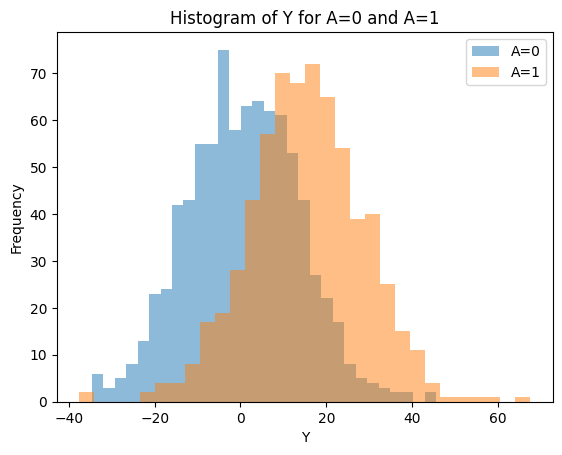

In [7]:
# simulate a sample size of N = 1500
N = 1500

A = np.random.binomial(1,0.4,N)

epsM = np.random.normal(0,np.sqrt(2),N)
epsX = np.random.normal(0,1,N)
epsY = np.random.normal(0,1,N)

M = 1.5*A + epsM
X = 2*M + 0.5*A + epsX
Y = 4*X + M + epsY

# split
Y0 = Y[A==0]
Y1 = Y[A==1]

# histogram
plt.hist(Y0, bins=30, alpha=0.5, label="A=0")
plt.hist(Y1, bins=30, alpha=0.5, label="A=1")

plt.legend()
plt.xlabel("Y")
plt.ylabel("Frequency")
plt.title("Histogram of Y for A=0 and A=1")

plt.show()

The two histograms have similar shapes and spreads.

The distribution for A=1 is shifted to the right relative to A=0, reflecting the positive causal effect of A on Y.

### Question 2 (b)

In [13]:
# theoretical total causal effect
total_effect = 15.5
print("Theoretical total causal effect of A on Y =", total_effect)

# covariance between A and Y
cov_AY = np.cov(A, Y, ddof=1)[0, 1]
print("Sample Cov(A, Y) =", cov_AY)

# theoretical covariance
theoretical_cov = total_effect * np.var(A, ddof=1)
print("Approx. theoretical covariance using sample Var(A) =", theoretical_cov)

Theoretical total causal effect of A on Y = 15.5
Sample Cov(A, Y) = 3.599106564521411
Approx. theoretical covariance using sample Var(A) = 3.8113800311318657


Since A is exogenous and independent of the noise terms, the covariance is proportional to the total causal effect.

Cov(A,Y)=15.5⋅Var(A)

### Question 3 (c)

In [ ]:
# Regression: Y ~ A
X_reg1 = sm.add_constant(A)   # add intercept
model1 = sm.OLS(Y, X_reg1).fit()

print("\nRegression (1): Y ~ A")
print(model1.summary())

beta_A_model1 = model1.params[1]
print("Estimated coefficient of A in model (1):", beta_A_model1)


Regression (1): Y ~ A
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     455.6
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           1.78e-88
Time:                        20:50:30   Log-Likelihood:                -5993.8
No. Observations:                1500   AIC:                         1.199e+04
Df Residuals:                    1498   BIC:                         1.200e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6382      0.

In [14]:
# Regression: Y ~ A + X
X_reg2 = np.column_stack((A, X))
X_reg2 = sm.add_constant(X_reg2)

model2 = sm.OLS(Y, X_reg2).fit()

print("\nRegression (2): Y ~ A + X")
print(model2.summary())

beta_A_model2 = model2.params[1]
beta_X_model2 = model2.params[2]

print("Estimated coefficient of A in model (2):", beta_A_model2)
print("Estimated coefficient of X in model (2):", beta_X_model2)


Regression (2): Y ~ A + X
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 1.330e+05
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:30:36   Log-Likelihood:                -2303.9
No. Observations:                1500   AIC:                             4614.
Df Residuals:                    1497   BIC:                             4630.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0344    

In model (1), the coefficient on A estimates the total effect of A on Y, so it should be close to 15.5.

In model (2), we control for X, which is a post-treatment variable / mediator. Therefore, the coefficient on A no longer captures the total effect.

### Question 3 (d)

In [29]:
# (d) Repeat with larger noise variance = 8
N = 1500

A2 = np.random.binomial(1, 0.4, N)

epsM2 = np.random.normal(0, np.sqrt(8), N)
epsX2 = np.random.normal(0, np.sqrt(8), N)
epsY2 = np.random.normal(0, np.sqrt(8), N)

M2 = 1.5 * A2 + epsM2
X2 = 2 * M2 + 0.5 * A2 + epsX2
Y2 = 4 * X2 + M2 + epsY2

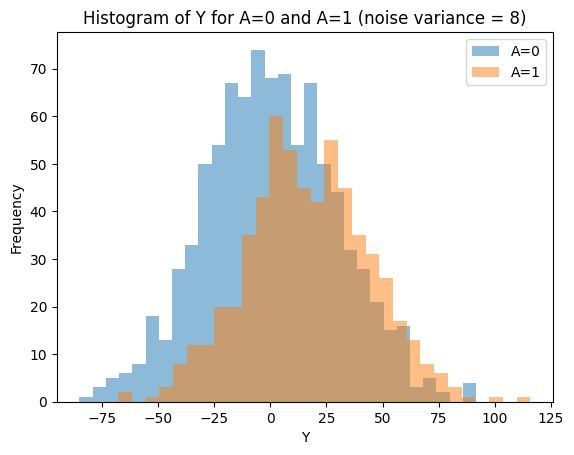

In [30]:
Y0_2 = Y2[A2 == 0]
Y1_2 = Y2[A2 == 1]

plt.hist(Y0_2, bins=30, alpha=0.5, label="A=0")
plt.hist(Y1_2, bins=30, alpha=0.5, label="A=1")

plt.legend()
plt.xlabel("Y")
plt.ylabel("Frequency")
plt.title("Histogram of Y for A=0 and A=1 (noise variance = 8)")
plt.show()

In [33]:
cov_AY_2 = np.cov(A2, Y2, ddof=1)[0, 1]
print("With noise variance = 8, sample Cov(A, Y) =", cov_AY_2)

With noise variance = 8, sample Cov(A, Y) = 3.85024095647574


In [35]:
# Regression (1): Y2 ~ A2
X2_reg1 = sm.add_constant(A2)
model1_d = sm.OLS(Y2, X2_reg1).fit()

print("\nRegression (1) with noise variance = 8: Y ~ A")
print(model1_d.summary())
print("Estimated coefficient of A in model (1):", model1_d.params[1])


Regression (1) with noise variance = 8: Y ~ A
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     112.8
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           1.90e-25
Time:                        21:36:40   Log-Likelihood:                -7160.7
No. Observations:                1500   AIC:                         1.433e+04
Df Residuals:                    1498   BIC:                         1.434e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

In [36]:
# Regression (2): Y2 ~ A2 + X2
X2_reg2 = np.column_stack((A2, X2))
X2_reg2 = sm.add_constant(X2_reg2)

model2_d = sm.OLS(Y2, X2_reg2).fit()

print("\nRegression (2) with noise variance = 8: Y ~ A + X")
print(model2_d.summary())
print("Estimated coefficient of A in model (2):", model2_d.params[1])
print("Estimated coefficient of X in model (2):", model2_d.params[2])


Regression (2) with noise variance = 8: Y ~ A + X
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 6.987e+04
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:36:43   Log-Likelihood:                -3804.9
No. Observations:                1500   AIC:                             7616.
Df Residuals:                    1497   BIC:                             7632.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c

Increasing the error variances makes the distributions of Y much more dispersed, so the two histograms overlap more strongly. 

But the structural coefficients are unchanged, so the underlying causal effect of A on Y remains the same. 

The estimated regression coefficients are therefore centered around similar theoretical values, but they become noisier due to the larger random variation.